In [1]:
%load_ext autoreload
%autoreload 2

## 1. Imports

In [2]:
import os
import sys

sys.path.append("..")

import random

import numpy as np
import torch
import torch.distributions as TD
import torch.nn as nn
from tqdm import tqdm

import wandb
from src.models.energy_based import EGEOT, EBMConfig
from src.models.utils import FullyConnectedMLP, MLPCost
from src.samplers.energy_based.sample_buffer import SampleBufferEgEOT
from src.samplers.from_dataset import DatasetSampler
from src.samplers.primary import StandardNormalSampler, SwissRollSampler
from src.utils.discrete_ot import OTPlanSampler
from src.utils.paired import generate_paired_data, get_GT_points, get_paired_sampler
from src.utils.plotting.distributions import plot_swiss_roll
from src.utils.train import update_average

In [3]:
device = torch.device(f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [4]:
torch.set_default_device(device)
dtype = torch.float64
torch.torch.set_default_dtype(dtype)

## 2. Config

In [5]:
X_DIM = 2
Y_DIM = 2
assert X_DIM > 1
assert Y_DIM > 1

OUTPUT_SEED = 42

BATCH_SIZE = 1024
SAMPLING_BATCH_SIZE = 128

D_LR_PAIRED = 1e-4  # 1e-3 for eps 0.1, 0.01 and 3e-4 for eps 0.002
D_LR_UNPAIRED = 2e-4
BETAS_PAIRED = (0.2, 0.99)
BETAS_UNPAIRED = (0.2, 0.99)
D_GRADIENT_MAX_NORM = float("inf")

M_X_UNPAIRED_SAMPLES = 1024
N_Y_UNPAIRED_SAMPLES = 1024
L_PAIRED_SAMPLES = 128

PLOT_EVERY = 10
MAX_STEPS = 200
CONTINUE = -1

EXP_COST = "MLP"
EXP_COST_INCLUDED = True
MINIBATCH_COST = "rotation-v2"

EMA_UPDATE = False

In [6]:
torch.manual_seed(OUTPUT_SEED)
np.random.seed(OUTPUT_SEED)
random.seed(OUTPUT_SEED)

In [7]:
# TODO: refactor this config
EXP_META_INFO = ""
EXP_NAME = (
    "EgEOT_Swiss_Roll_"
    + f"MAX_STEPS_{MAX_STEPS}_"
    + f"with_{EXP_COST}_cost_included_{EXP_COST_INCLUDED}_"
    + f"M_X_UNPAIRED_{M_X_UNPAIRED_SAMPLES}_"
    + f"N_Y_UNPAIRED_{N_Y_UNPAIRED_SAMPLES}_"
    + f"L_PAIRED_{L_PAIRED_SAMPLES}_"
    + f"LR_PAIRED_{D_LR_PAIRED}_"
    + f"LR_UNPAIRED_{D_LR_UNPAIRED}_"
    + f"MINIBATCH_COST_{MINIBATCH_COST}_"
    + EXP_META_INFO
)
OUTPUT_PATH = "../checkpoints/{}".format(EXP_NAME)

config = dict(
    X_DIM=X_DIM,
    Y_DIM=Y_DIM,
    D_LR_PAIRED=D_LR_PAIRED,
    D_LR_UNPAIRED=D_LR_UNPAIRED,
    BATCH_SIZE=BATCH_SIZE,
    D_GRADIENT_MAX_NORM=D_GRADIENT_MAX_NORM,
    M_X_UNPAIRED_SAMPLES=M_X_UNPAIRED_SAMPLES,
    N_Y_UNPAIRED_SAMPELS=N_Y_UNPAIRED_SAMPLES,
    L_PAIRED_SAMPLES=L_PAIRED_SAMPLES,
)

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

## 3. Create data and samplers

In [8]:
X_sampler = StandardNormalSampler(dim=2, device=device)
Y_sampler = SwissRollSampler(dim=2, device=device, dtype=dtype)

In [9]:
otp_sampler = OTPlanSampler("sinkhorn", cost_function=MINIBATCH_COST)

In [10]:
data_dir = "checkpoints/Tensors"
file_postfix = f"{MINIBATCH_COST}_{L_PAIRED_SAMPLES}"

In [11]:
X_paired_train, Y_paired_train, X_paired_test, Y_paired_test = generate_paired_data(
    X_sampler, Y_sampler, otp_sampler, L_PAIRED_SAMPLES, "./checkpoints/Tensors", file_postfix, device=device
)

/beegfs/home/m.persiyanov/Light-GCOT/src/utils/paired.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_paired_train = torch.load(os.path.join(save_dir, f"X_paired_trai

In [12]:
pd_train_sampler = get_paired_sampler(X_paired_train, Y_paired_train, BATCH_SIZE, L_PAIRED_SAMPLES, device)

In [13]:
X_unpaired_test = X_sampler.sample(L_PAIRED_SAMPLES)
Y_unpaired_test = Y_sampler.sample(L_PAIRED_SAMPLES)

In [14]:
if M_X_UNPAIRED_SAMPLES > 0:
    source_data = X_sampler.sample(M_X_UNPAIRED_SAMPLES)
    usd_sampler = DatasetSampler(source_data, device=device) # usd - unpaired source data
else:
    usd_sampler = DatasetSampler(X_paired_train, device=device)

if N_Y_UNPAIRED_SAMPLES > 0:
    target_data = Y_sampler.sample(N_Y_UNPAIRED_SAMPLES)
    utd_sampler = DatasetSampler(target_data, device=device) # utd - unpaired target data
else:
    utd_sampler = DatasetSampler(Y_paired_train, device=device)

## 4. Model initialization

In [15]:
config = EBMConfig()

In [16]:
# TODO: add config for the potential
potential = FullyConnectedMLP(
    input_dim=2, hiddens=[256, 256, 256], output_dim=1, activation_gen=lambda: nn.LeakyReLU(0.2)
)

In [17]:
N_POTENTIALS = 50
M_POTENTIALS = 25
EPSILON = 1.0

In [18]:
# TODO: add config for the cost
cost = MLPCost(X_DIM, Y_DIM, N_POTENTIALS, M_POTENTIALS, EPSILON)

In [19]:
# TODO: add to config
BASIC_NOISE_VAR = 1.0
P_SAMPLE_BUFFER_REPLAY = 0.95
SAMPLE_BUFFER_SAMPLES = 10000

In [20]:
basic_noise_gen = TD.Normal(torch.tensor([0.0, 0.0]).to(device), torch.tensor([1.0, 1.0]).to(device) * BASIC_NOISE_VAR)

sample_buffer_instance = SampleBufferEgEOT(
    basic_noise_gen, p=P_SAMPLE_BUFFER_REPLAY, max_samples=SAMPLE_BUFFER_SAMPLES, device=device
)

In [21]:
model = EGEOT(potential, cost, sample_buffer_instance, config)

In [22]:
unpaired_params_to_update = model.potential.parameters()

D_opt_unpaired = torch.optim.Adam(unpaired_params_to_update, lr=D_LR_UNPAIRED, betas=BETAS_UNPAIRED)

In [23]:
paired_params_to_update = model.cost.parameters()

D_opt_paired = torch.optim.Adam(paired_params_to_update, lr=D_LR_PAIRED, betas=BETAS_PAIRED)

In [24]:
if CONTINUE > -1:
    D_opt_unpaired.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_unpaired_{CONTINUE}.pt")))
    D_opt_paired.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_paired_{CONTINUE}.pt")))

In [25]:
# For EMA update
if EMA_UPDATE:
    model_copy = EGEOT(potential, cost, sample_buffer_instance, config)

## 5. Model training

In [26]:
starting_points = torch.tensor([[-2.0, 0.0], [0.0, 0.0], [0.0, -2.0]])
num_ending_points = 64

In [27]:
num_starting_points_paired = 5
indices = random.choices(range(L_PAIRED_SAMPLES), k=num_starting_points_paired)
starting_points_paired = X_paired_train[indices]
ending_points_paired = Y_paired_train[indices]

In [28]:
gt_Y_points = get_GT_points(X_sampler, Y_sampler, otp_sampler, starting_points)

  2%|██▌                                                                                                                                                                | 1/64 [00:00<00:18,  3.33it/s]/trinity/home/m.persiyanov/miniconda3/envs/text/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:531: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn("Sinkhorn did not converge. You might want to "
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [00:00<00:00, 83.60it/s]


In [29]:
def compute_loss(
    model: EGEOT,
    X_unpaired: torch.Tensor,
    Y_unpaired: torch.Tensor,
    X_paired: torch.Tensor,
    Y_paired: torch.Tensor,
) -> torch.Tensor:
    output = model.compute_unpaired_loss(X_unpaired, Y_unpaired)
    loss_paired = model.compute_paired_loss(X_paired, Y_paired)

    return loss_paired + output["loss"]

In [31]:
MAX_STEPS *= 5

In [32]:
wandb.init(name=EXP_NAME, config=config)

for step in tqdm(range(CONTINUE + 1, MAX_STEPS)):
    # training loop
    D_opt_unpaired.zero_grad()

    X = usd_sampler.sample(BATCH_SIZE)
    Y = utd_sampler.sample(BATCH_SIZE)

    output = model.compute_unpaired_loss(X, Y)

    D_loss_unpaired = output["loss"]
    wandb.log({f"D unpaired loss": D_loss_unpaired.item()}, step=step)

    wandb.log({f"Pos Out Mean": output["pos_out"].item()}, step=step)
    wandb.log({f"Neg Out Mean": output["neg_out"].item()}, step=step)
    wandb.log({f"D unpaired loss": D_loss_unpaired.item()}, step=step)
    wandb.log({f"r_t": output["r_t"].item()}, step=step)
    wandb.log({f"cost_r_t": output["cost_r_t"].item()}, step=step)
    wandb.log({f"score_r_t": output["score_r_t"].item()}, step=step)
    wandb.log({f"noise": output["noise"].item()}, step=step)

    if EXP_COST_INCLUDED:
        D_opt_paired.zero_grad()
        X_paired, Y_paired = pd_train_sampler.sample(BATCH_SIZE)
        
        D_loss_paired = model.compute_paired_loss(X_paired, Y_paired)

        wandb.log({f"D paired loss": D_loss_paired.item()}, step=step)

    D_loss = D_loss_unpaired + D_loss_paired
    D_loss.backward()
    D_opt_paired.step()
    D_opt_unpaired.step()

    D_unpaired_gradient_norm = torch.nn.utils.clip_grad_norm_(unpaired_params_to_update, max_norm=D_GRADIENT_MAX_NORM)
    wandb.log({f"D unpaired gradient norm": D_unpaired_gradient_norm.item()}, step=step)
    D_paired_gradient_norm = torch.nn.utils.clip_grad_norm_(paired_params_to_update, max_norm=D_GRADIENT_MAX_NORM)
    wandb.log({f"D paired gradient norm": D_paired_gradient_norm.item()}, step=step)
    
    if EMA_UPDATE:
        update_average(model_copy, model, 0.99)
        model = model_copy
    else:
        model = model

    wandb.log({f"D loss": D_loss}, step=step)
    wandb.log(
        {f"Train paired loss": compute_loss(model, X_paired_train, Y_paired_train, X_paired_train, Y_paired_train)},
        step=step,
    )
    wandb.log(
        {f"Test paired loss": compute_loss(model, X_paired_test, Y_paired_test, X_paired_test, Y_paired_test)},
        step=step,
    )
    wandb.log(
        {f"Test unpaired loss": compute_loss(model, X_unpaired_test, Y_unpaired_test, X_paired_test, Y_paired_test)},
        step=step,
    )

    if step % PLOT_EVERY == 0:
        distr_dict = plot_swiss_roll(
            {"EBM": model},
            X_sampler,
            Y_sampler,
            X_paired_train,
            Y_paired_train,
            starting_points,
            gt_Y_points,
            log=True,
        ) 
        wandb.log(distr_dict)
        torch.save(model.potential.state_dict(), os.path.join(OUTPUT_PATH, f"potential_{step}.pt"))

torch.save(model.potential.state_dict(), os.path.join(OUTPUT_PATH, f"D_{MAX_STEPS}.pt"))
torch.save(D_opt_paired.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt_paired_{MAX_STEPS}.pt"))
torch.save(D_opt_unpaired.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt_unpaired_{MAX_STEPS}.pt"))

wandb.finish()

  1%|█▋                                                                                                                                                            | 11/1000 [01:05<1:50:01,  6.68s/it]

## Plotting

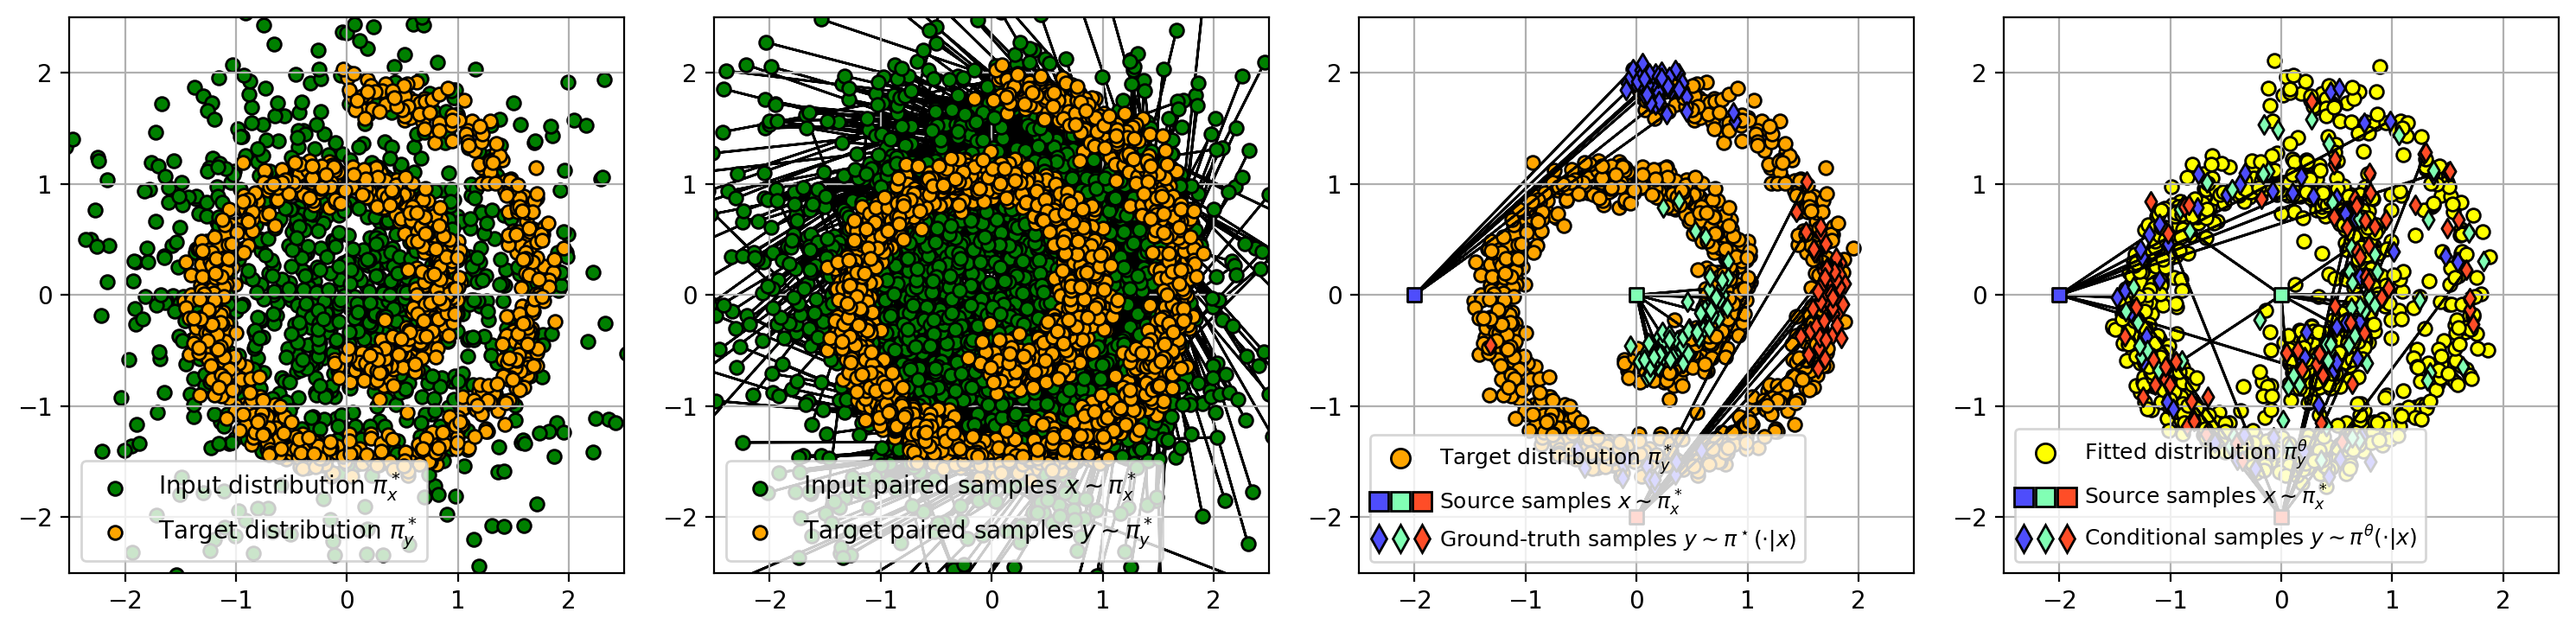

In [33]:
plot_swiss_roll(
    {"EBM": model},
    X_sampler,
    Y_sampler,
    X_paired_train,
    Y_paired_train,
    starting_points,
    gt_Y_points,
) 